# Model híbrid: SARIMA-NNAR - Sèrie Temporal 4

## Objectiu:

Aquest notebook se centra en el desenvolupament d'un model híbrid per a la sèrie temporal de casos de Faringoamigdalitis a Barcelona Nord en infants de menys de 15 anys, utilitzant dades setmanals per al període 2012-2024.

Consisteix a agafar el model SARIMA trobat en el notebook "01_SARIMA_serie1", el qual captura l'estructura lineal i estacional de la sèrie; i incorporar un model autoregressiu de xarxa neuronal (NNAR) amb l'objectiu de modelitzar possibles patrons no lineals en els residus del SARIMA.
De manera que la predicció híbrida final s'obté combinant la predicció SARIMA amb la predicció dels residus amb NNAR.

En particular, la xarxa neuronal usa com a entrades els retards més recents dels residus i un retard estacional de 52 setmanes, d'aquesta manera es manté coherència amb l'estacionalitat anual de la sèrie setmanal.

## Metodologia

El procediment és el següent:

- Carregar el model SARIMA i ajustar-lo sobre el període d'entrenament
- Extreure els resius del SARIMA i dur a terme una anàlisi exploratòria per valorar si encara contenen estructura a modelitzar
- Construir una matriu d'aprenentatge supervisat a partir dels residus, utilitzant retards de curt termini i un retard estacional
- Dividir la sèrie de residus en entrenament i validació, preservant l'ordre temporal
- Cercar la millor combinació de nombre de retards curts i d'unitats ocultes mitjançant una graella de cerca
- Reajustar la xarxa neuronal seleccionada sobre tot el conjunt d'entrenament dels residus
- Generar prediccions recursives i combinar-les additivament amb les prediccions del SARIMA
- Fer una simulació de la cobertura del model híbrid mitjançant bootstrap.
- Observar a través de mètriques (MAE, RMSE, MAPE) i de manera visual la millora del model híbrid respecte del SARIMA


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import acf
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

COLOR_TRAIN = '#1f77b4'   
COLOR_OBS = '#ffbf00'      
COLOR_FORECAST = '#6a0dad' 
COLOR_HYBRID = "#009688" #o "#C2185B" 

df = pd.read_csv("dades_net.csv", sep=",")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["nom_regio", "diagnostic", "edat_bin", "date"]).copy()

In [2]:
df_serie = df[
    (df["diagnostic"] == "Faringoamigdalitis") &
    (df["nom_regio"] == "Barcelona Metropolitana Nord") &
    (df["edat_bin"] == "0-14")
]

serie = (
    df_serie.groupby("date")["taxa_setmanal"]
    .sum()
    .sort_index()
)
serie = serie.asfreq("W-MON")

In [3]:
serie_4 = serie.copy()

train = serie_4[serie_4.index < "2020-01-01"]
test  = serie_4[serie_4.index >= "2020-01-01"]

train = train.interpolate()
test = test.interpolate()

2012-01-02 00:00:00 2019-12-30 00:00:00
2020-01-06 00:00:00 2024-12-23 00:00:00


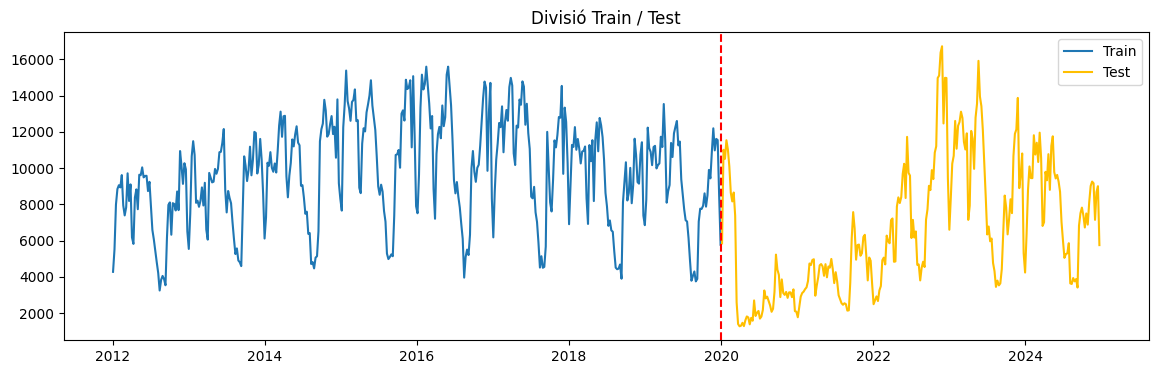

In [4]:
print(train.index.min(), train.index.max())
print(test.index.min(), test.index.max())

plt.figure(figsize=(14,4))

plt.plot(train, label="Train", color=COLOR_TRAIN, linewidth=1.5)
plt.plot(test, label="Test", color=COLOR_OBS, linewidth=1.5)

plt.axvline(train.index.max(), color="red", linestyle="--")

plt.legend()
plt.title("Divisió Train / Test")
plt.show()

In [5]:
model = SARIMAX(train,
                order=(1,1,1),
                seasonal_order=(0,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False)
result = model.fit(disp=False)

## Extracció de residus i anàlisi exploratòria

En aquesta secció, s’extreuen els residus del model SARIMA ajustat sobre el conjunt d’entrenament. Aquests residus representen la part de la sèrie que queda sense explicar després de modelitzar-ne el comportament lineal i estacional principal.

Un cop extrets els residus, es duu a terme una anàlisi exploratòria. Primer, se’n calculen els principals estadístics descriptius. Després, es representen els residus al llarg del temps per inspeccionar-ne el comportament general. 
La seva distribució s’examina mitjançant un QQ-plot, mentre que també s’inclou un gràfic de dispersió per visualitzar-ne la variabilitat i detectar possibles observacions atípiques.

La seva estructura de dependència s’analitza mitjançant la funció d’autocorrelació (ACF). I s’estudia l’autocorrelació dels residus al quadrat per detectar possibles efectes en la variància o patrons no lineals restants. 

Finalment, s’inclouen proves estadístiques formals: el test de Ljung–Box s’utilitza per avaluar l’autocorrelació restant, i el test ARCH s’utilitza per detectar heteroscedasticitat condicional.

L’objectiu d’aquest pas és avaluar si els residus es comporten aproximadament com a soroll blanc o si encara contenen estructura que pugui justificar l’ús d’un model NNAR.

Burn-in utilitzat: 107
Mitjana dels residus: -123.14899502092321
Desviació estàndard dels residus: 1304.30069078186
Mitjana relativa (|mitjana| / desviació estàndard): 0.09441764149270045


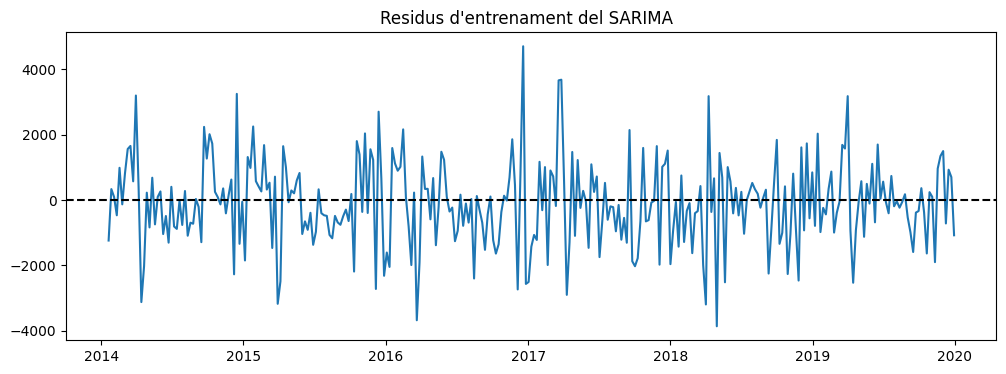

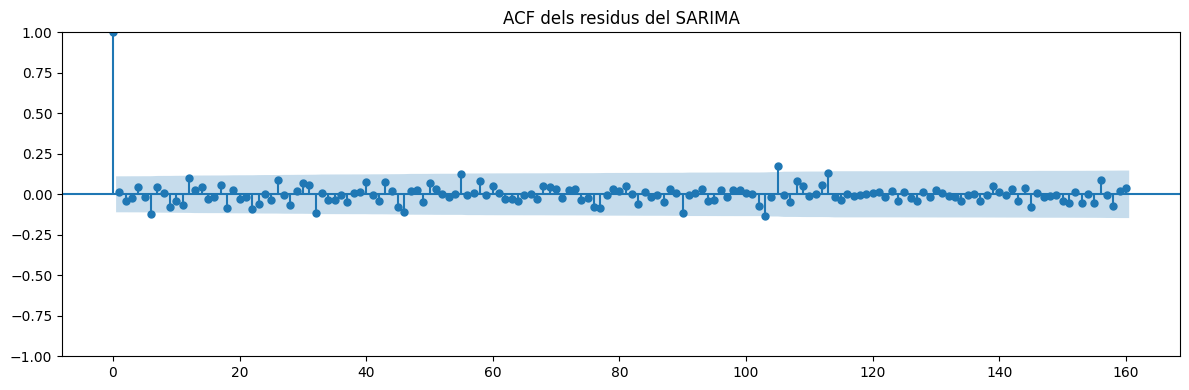


Ljung-Box test:
      lb_stat  lb_pvalue
10   9.474886   0.487704
20  19.336789   0.500041
30  29.860314   0.472824

Test de Ljung-Box en retards estacionals:
       lb_stat  lb_pvalue
52   51.889447   0.478231
104  97.270501   0.666609


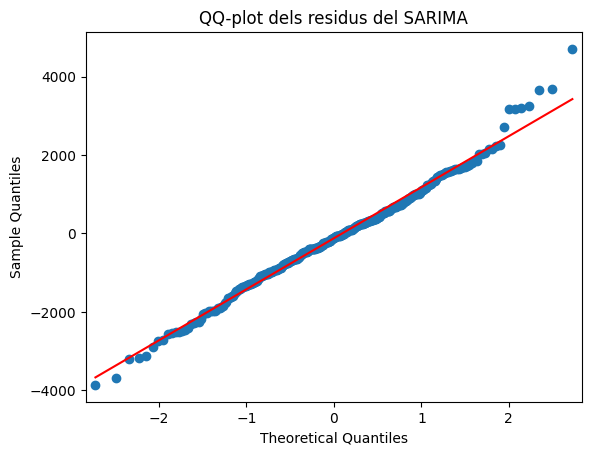

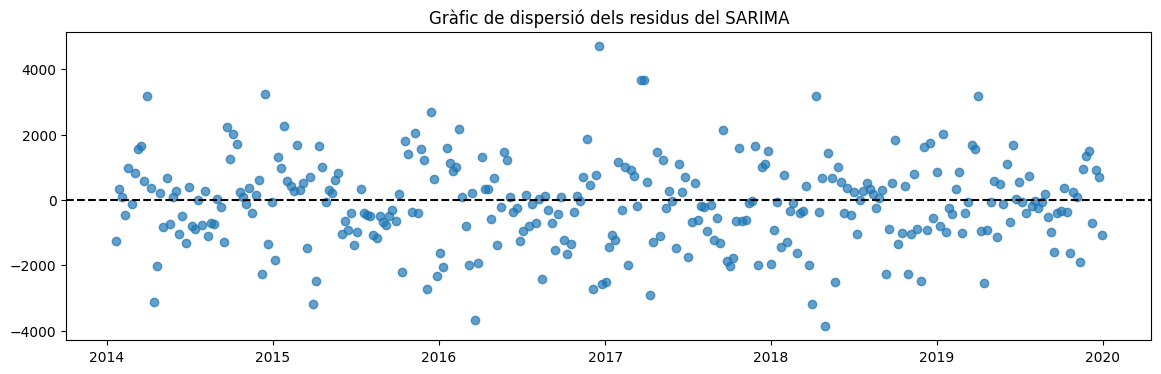

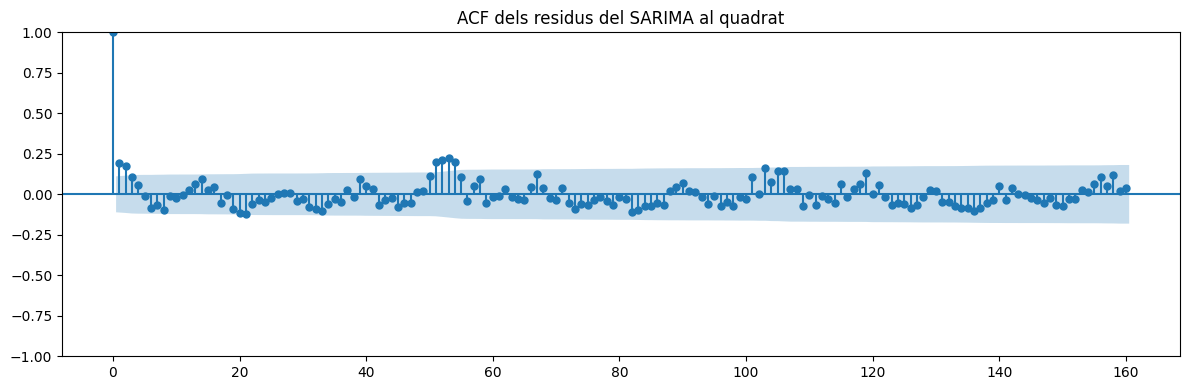


p-valor del test ARCH: 0.011340327615165046


In [6]:
residuals= result.resid.dropna()
burn = max(result.loglikelihood_burn, result.filter_results.nobs_diffuse)

print(f"Burn-in utilitzat: {burn}")
residuals_train = residuals.iloc[burn:].copy()

print("Mitjana dels residus:", residuals_train.mean())
print("Desviació estàndard dels residus:", residuals_train.std())
print("Mitjana relativa (|mitjana| / desviació estàndard):", abs(residuals_train.mean()) / residuals_train.std())

plt.figure(figsize=(12, 4))
plt.plot(residuals_train)
plt.axhline(0, color="black", linestyle="--")
plt.title("Residus d'entrenament del SARIMA  ")
plt.show()

fig, ax = plt.subplots(figsize=(12, 4)) 
plot_acf(residuals_train, lags=160, ax=ax)

ax.set_title("ACF dels residus del SARIMA")
plt.tight_layout()
plt.show()

ljung_box = acorr_ljungbox(residuals_train, lags=[10, 20, 30], return_df=True)
print("\nLjung-Box test:")
print(ljung_box)

ljung_box_seasonal = acorr_ljungbox(residuals_train,lags=[52, 104],return_df=True)

print("\nTest de Ljung-Box en retards estacionals:")
print(ljung_box_seasonal)

sm.qqplot(residuals_train, line="s")
plt.title("QQ-plot dels residus del SARIMA")
plt.show()

plt.figure(figsize=(14, 4))
plt.scatter(residuals_train.index, residuals_train, alpha=0.7)
plt.axhline(0, color="black", linestyle="--")
plt.title("Gràfic de dispersió dels residus del SARIMA")
plt.show()

fig, ax = plt.subplots(figsize=(12, 4)) 
plot_acf(residuals_train**2, lags=160, ax=ax)

ax.set_title("ACF dels residus del SARIMA al quadrat")
plt.tight_layout()
plt.show()

arch_test = het_arch(residuals_train, nlags=10)
print("\np-valor del test ARCH:", arch_test[1])

## Resultats de l’anàlisi exploratòria dels residus

Els diagnòstics dels residus suggereixen que el model SARIMA captura una gran part de l’estructura lineal i estacional de la sèrie. 
Els residus fluctuen al voltant de zero i l’autocorrelació restant és feble en general, tot i que encara s’observen alguns petits pics a l’ACF dels residus.
El QQ-plot és força proper a una línia recta, amb algunes desviacions a les cues. A més, l’ACF dels residus al quadrat mostra una estructura més visible, especialment al voltant de retards estacionals com el 52 i el 104, i el test ARCH és significatiu. Això suggereix que, tot i que s’han eliminat la majoria de les dinàmiques lineals principals, encara poden quedar alguns patrons estacionals no lineals o relacionats amb la variància.

Per aquest motiu, s’explora un model NNAR estacional com a pas complementari, amb l’objectiu d’avaluar si aquests patrons restants poden proporcionar una millora predictiva modesta.

## Construcció de la matriu supervisada de residus

Per ajustar la xarxa neuronal, la sèrie de residus del SARIMA es transforma en un problema d’aprenentatge supervisat.
Per a cada observació, les variables predictores són:
- els p valors residuals anteriors, que representen la dependència a curt termini
- un retard estacional de 52 setmanes, que representa la dependència estacional anual
  
La variable objectiu és el valor residual actual. Després de desplaçar la sèrie per crear aquestes variables predictores, s’eliminen les observacions inicials amb valors absents en els retards.

Aquesta transformació permet tractar la sèrie temporal de residus com un problema de regressió, tot preservant-ne l’estructura temporal.

In [7]:
SEASONAL_LAG = 52

ROLLING_START_FRAC = 0.7
ROLLING_HORIZON = 26
ROLLING_STEP = 26

p_list = [2, 3, 4, 5, 6, 8, 12]
hidden_list = [2, 3, 4, 6, 8]

def create_nnar_matrix(series, p=2, seasonal_lag=52):
    df = pd.DataFrame({"y": series})

    for i in range(1, p + 1):
        df[f"lag_{i}"] = series.shift(i)

    df[f"lag_seasonal_{seasonal_lag}"] = series.shift(seasonal_lag)

    df = df.dropna()

    X = df.drop(columns="y")
    y = df["y"]

    return X, y

## Graella dels hiperparàmetres del NNAR estacional

Es realitza una petita cerca en graella per determinar l’especificació del model NNAR estacional més adequada per a la sèrie de residus.

S’exploren dos hiperparàmetres:
- p: nombre de retards curts dels residus utilitzats com a entrades
- h: nombre de neurones de la capa oculta
  
El component estacional es fixa en un retard de 52 setmanes, de manera que el model es pot interpretar com una estructura NNAR estacional simple (p, P, h, m) amb:
- P = 1
- m = 52
  
Els models candidats s’avaluen mitjançant un esquema de 'rolling validation', més adequat per a sèries temporals que una única partició fixa. 
En cada partició, el model s’entrena amb la part inicial de la sèrie de residus i després s’utilitza per predir recursivament el bloc de validació següent. Posteriorment, la finestra d’entrenament s’amplia i el procés es repeteix en diverses iteracions.
Els models es comparen utilitzant el rolling MAE i el rolling RMSE. 

En aquest notebook, es dona més importància al rolling RMSE, ja que penalitza amb més intensitat els errors de predicció grans.

In [8]:
results_grid = []

n_total = len(residuals_train)
min_start = SEASONAL_LAG + max(p_list) + 10
start = max(int(np.floor(ROLLING_START_FRAC * n_total)), min_start)

for p in p_list:
    for hidden in hidden_list:
        fold_mae_list = []
        fold_rmse_list = []
        n_folds = 0

        end_train = start

        while end_train + ROLLING_HORIZON <= n_total:
            train_cv = residuals_train.iloc[:end_train].copy()
            val_cv = residuals_train.iloc[end_train:end_train + ROLLING_HORIZON].copy()

            X_train_nn, y_train_nn = create_nnar_matrix(
                train_cv,
                p=p,
                seasonal_lag=SEASONAL_LAG
            )

            if len(X_train_nn) == 0:
                end_train += ROLLING_STEP
                continue

            scaler_X = StandardScaler()
            scaler_y = StandardScaler()

            X_train_scaled = scaler_X.fit_transform(X_train_nn)
            y_train_scaled = scaler_y.fit_transform(y_train_nn.to_frame()).ravel()

            nnar_model = MLPRegressor(
                hidden_layer_sizes=(hidden,),
                activation="relu",
                solver="lbfgs",
                alpha=1e-4,
                max_iter=5000,
                random_state=42
            )

            nnar_model.fit(X_train_scaled, y_train_scaled)

            history = list(train_cv.values)
            pred_cv = []

            for _ in range(len(val_cv)):
                row_next = {}

                for i in range(1, p + 1):
                    row_next[f"lag_{i}"] = history[-i]

                row_next[f"lag_seasonal_{SEASONAL_LAG}"] = history[-SEASONAL_LAG]

                X_next = pd.DataFrame([row_next], columns=X_train_nn.columns)
                X_next_scaled = scaler_X.transform(X_next)

                pred_next_scaled = nnar_model.predict(X_next_scaled)
                pred_next = scaler_y.inverse_transform(
                    pred_next_scaled.reshape(-1, 1)
                ).ravel()[0]

                pred_cv.append(pred_next)
                history.append(pred_next)

            pred_cv = pd.Series(pred_cv, index=val_cv.index)

            mae_cv = mean_absolute_error(val_cv, pred_cv)
            rmse_cv = root_mean_squared_error(val_cv, pred_cv)

            fold_mae_list.append(mae_cv)
            fold_rmse_list.append(rmse_cv)
            n_folds += 1

            end_train += ROLLING_STEP

        if n_folds > 0:
            results_grid.append({
                "p": p,
                "P": 1,
                "m": SEASONAL_LAG,
                "hidden_units": hidden,
                "rolling_MAE": np.mean(fold_mae_list),
                "rolling_RMSE": np.mean(fold_rmse_list),
                "n_folds": n_folds
            })

results_grid = (
    pd.DataFrame(results_grid)
    .sort_values(["rolling_RMSE", "rolling_MAE"])
    .reset_index(drop=True)
)

print("\nTop 5 configuracions segons el rolling MAE")
display(
    results_grid
    .sort_values(["rolling_MAE", "rolling_RMSE"])
    .head(5)
    .reset_index(drop=True)
    .rename(columns={
        "hidden_units": "neurones_ocultes",
        "rolling_MAE": "MAE_rolling",
        "rolling_RMSE": "RMSE_rolling",
        "n_folds": "n_folds"
    })
)

print("\nTop 5 configuracions segons el rolling RMSE")
display(
    results_grid
    .sort_values(["rolling_RMSE", "rolling_MAE"])
    .head(5)
    .reset_index(drop=True)
    .rename(columns={
        "hidden_units": "neurones_ocultes",
        "rolling_MAE": "MAE_rolling",
        "rolling_RMSE": "RMSE_rolling",
        "n_folds": "n_folds"
    })
)


Top 5 configuracions segons el rolling MAE


,p,P,m,neurones_ocultes,MAE_rolling,RMSE_rolling,n_folds
0,2,1,52,2,941.905145,1261.829758,3
1,12,1,52,2,945.285296,1284.270405,3
2,4,1,52,3,951.060436,1295.534788,3
3,3,1,52,4,968.446368,1316.296235,3
4,5,1,52,2,972.001868,1312.709612,3



Top 5 configuracions segons el rolling RMSE


,p,P,m,neurones_ocultes,MAE_rolling,RMSE_rolling,n_folds
0,2,1,52,2,941.905145,1261.829758,3
1,5,1,52,3,989.042961,1264.452813,3
2,12,1,52,2,945.285296,1284.270405,3
3,4,1,52,3,951.060436,1295.534788,3
4,5,1,52,2,972.001868,1312.709612,3


In [9]:
best_config = results_grid[
    (results_grid["p"] == 2) &
    (results_grid["hidden_units"] == 2)
].iloc[0]

best_p = int(best_config["p"])
best_hidden = int(best_config["hidden_units"])

print("NNAR estacional seleccionada:")
print(f"p = {best_p}")
print("P = 1")
print(f"m = {SEASONAL_LAG}")
print(f"neurones ocultes = {best_hidden}")
print(f"Rolling MAE = {best_config['rolling_MAE']:.6f}")
print(f"Rolling RMSE = {best_config['rolling_RMSE']:.6f}")
print(f"Nombre de folds de validació = {best_config['n_folds']}")

NNAR estacional seleccionada:
p = 2
P = 1
m = 52
neurones ocultes = 2
Rolling MAE = 941.905145
Rolling RMSE = 1261.829758
Nombre de folds de validació = 3.0


## Ajust final del NNAR estacional sobre tot el conjunt d’entrenament dels residus

Per a aquesta sèrie, el model NNAR estacional seleccionat és **NNAR(p=2, P=1, h=2, m=52)**.

Un cop seleccionats els millors hiperparàmetres, el model NNAR estacional s’ajusta novament utilitzant tot el conjunt d’entrenament dels residus. Aquest ajust final aprofita tota la informació residual disponible del període d’entrenament, de manera que la xarxa neuronal es pugui utilitzar per generar prediccions recursives per a l’horitzó de test.

In [10]:
X_full_nn, y_full_nn = create_nnar_matrix(residuals_train, p=best_p, seasonal_lag=SEASONAL_LAG)

scaler_X_final = StandardScaler()
scaler_y_final = StandardScaler()

X_full_scaled = scaler_X_final.fit_transform(X_full_nn)
y_full_scaled = scaler_y_final.fit_transform(y_full_nn.to_frame()).ravel()

nnar_final = MLPRegressor(
    hidden_layer_sizes=(best_hidden,),
    activation="relu",
    solver="lbfgs",
    alpha=1e-4,
    max_iter=5000,
    random_state=42
)

nnar_final.fit(X_full_scaled, y_full_scaled);

## Predicció recursiva dels residus i predicció híbrida

Les prediccions dels residus es generen de manera recursiva. Això vol dir que la xarxa neuronal prediu el següent valor residual utilitzant els retards disponibles més recents i el retard estacional. Després, cada residu predit s’incorpora a l’historial i s’utilitza per predir el següent. Aquesta estratègia recursiva és necessària perquè en l’horitzó de predicció, els residus futurs són desconeguts i, per tant, s’han de generar pas a pas.

Finalment, les prediccions dels residus obtingudes amb el model NNAR estacional s’afegeixen a les prediccions del SARIMA.

D’aquesta manera, el model híbrid combina:

- l’estructura lineal i estacional capturada pel SARIMA
- la possible estructura residual no lineal capturada pel model NNAR estacional

In [11]:
def recursive_nnar_forecast(model, history, horizon, p, seasonal_lag, scaler_X, scaler_y, forecast_index):
    preds = []
    history = list(history)

    for _ in range(horizon):
        row = {}

        for i in range(1, p + 1):
            row[f"lag_{i}"] = history[-i]

        row[f"lag_seasonal_{seasonal_lag}"] = history[-seasonal_lag]

        X_next = pd.DataFrame([row])
        X_next_scaled = scaler_X.transform(X_next)

        pred_scaled = model.predict(X_next_scaled)
        pred = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()[0]

        preds.append(pred)
        history.append(pred)

    return pd.Series(preds, index=forecast_index)

## Intervals de predicció per al model híbrid

Per al model SARIMA, els intervals de predicció s’obtenen directament del model ajustat.  
En el cas de l’enfocament híbrid SARIMA + NNAR, això no és tan directe, ja que el component de xarxa neuronal no proporciona intervals de predicció analítics exactes.

Per abordar-ho, els intervals híbrids es construeixen mitjançant simulació. Primer, se simulen trajectòries futures per al component SARIMA. Després, es generen recursivament trajectòries futures dels residus per al component NNAR, afegint errors passats remostrejats (*bootstrap*) per reflectir la incertesa. Finalment, es combinen totes dues parts i es prenen els quantils del 2,5% i del 97,5% de les trajectòries simulades com a límit inferior i superior de l’interval de predicció del 95%.

Per tant, aquests intervals s’han d’interpretar com a intervals de predicció empírics o aproximats, no com a intervals analítics exactes.

In [12]:
def hybrid_pi_short(
    sarima_result,
    nnar_model,
    scaler_X,
    scaler_y,
    residuals_train,
    X_train_nnar,
    y_train_nnar,
    p,
    seasonal_lag,
    forecast_index,
    n_sims=300,
    alpha=0.05,
    seed=42
):
    rng = np.random.default_rng(seed)
    h = len(forecast_index)

    X_scaled = scaler_X.transform(X_train_nnar)
    yhat_scaled = nnar_model.predict(X_scaled)
    yhat = scaler_y.inverse_transform(yhat_scaled.reshape(-1, 1)).ravel()

    nnar_errors = np.asarray(y_train_nnar) - yhat
    nnar_errors = nnar_errors - nnar_errors.mean()

    err_low, err_high = np.quantile(nnar_errors, [0.01, 0.99])
    nnar_errors = np.clip(nnar_errors, err_low, err_high)

    sarima_sim = np.asarray(
        sarima_result.simulate(
            nsimulations=h,
            repetitions=n_sims,
            anchor="end",
            random_state=seed
        )
    )

    if sarima_sim.ndim == 1:
        sarima_sim = sarima_sim.reshape(h, 1)
    elif sarima_sim.shape == (n_sims, h):
        sarima_sim = sarima_sim.T

    hybrid_sim = np.zeros((h, n_sims))
    base_history = list(np.asarray(residuals_train, dtype=float))

    resid_low, resid_high = np.quantile(base_history, [0.01, 0.99])

    for b in range(n_sims):
        history = base_history.copy()

        for t in range(h):
            row = {f"lag_{i}": history[-i] for i in range(1, p + 1)}
            row[f"lag_seasonal_{seasonal_lag}"] = history[-seasonal_lag]

            X_next = pd.DataFrame([row])
            X_next_scaled = scaler_X.transform(X_next)

            pred_scaled = nnar_model.predict(X_next_scaled)
            pred_resid = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()[0]

            next_resid = pred_resid + rng.choice(nnar_errors)
            next_resid = np.clip(next_resid, resid_low, resid_high)
            history.append(next_resid)

            total_pred = sarima_sim[t, b] + next_resid
            hybrid_sim[t, b] = total_pred

    lower = pd.Series(np.quantile(hybrid_sim, alpha / 2, axis=1), index=forecast_index)
    upper = pd.Series(np.quantile(hybrid_sim, 1 - alpha / 2, axis=1), index=forecast_index)
    median = pd.Series(np.quantile(hybrid_sim, 0.5, axis=1), index=forecast_index)

    return lower, upper, median

In [13]:
pred = result.get_forecast(steps=len(test))
pred_mean = pred.predicted_mean
pred_ci = pred.conf_int()

nnar_resid_forecast = recursive_nnar_forecast(
    model=nnar_final,
    history=residuals_train.values,
    horizon=len(test),
    p=best_p,
    seasonal_lag=SEASONAL_LAG,
    scaler_X=scaler_X_final,
    scaler_y=scaler_y_final,
    forecast_index=test.index
)

hybrid_pred_mean = pred_mean + nnar_resid_forecast

hybrid_ci_lower, hybrid_ci_upper, hybrid_ci_median = hybrid_pi_short(
    sarima_result=result,
    nnar_model=nnar_final,
    scaler_X=scaler_X_final,
    scaler_y=scaler_y_final,
    residuals_train=residuals_train,
    X_train_nnar=X_full_nn,     
    y_train_nnar=y_full_nn,     
    p=best_p,
    seasonal_lag=SEASONAL_LAG,
    forecast_index=test.index,
    n_sims=300,
    alpha=0.05,
    seed=42
)

## Model SARIMA vs model híbrid

El pas final consisteix a comparar el rendiment predictiu del model SARIMA i del model híbrid SARIMA + NNAR estacional sobre el període de test. La comparació es basa en el MAE, el RMSE i el MAPE, juntament amb el percentatge de millora del model híbrid respecte al model de referència SARIMA.

Per obtenir una avaluació més detallada, la comparació es fa sobre tot el període de test i, separadament, sobre els subperíodes COVID (2020–2021) i post-COVID (2022–2024). També es consideren els intervals de predicció: els intervals del SARIMA s’obtenen directament del model ajustat, mentre que els intervals híbrids s’aproximen mitjançant simulació. A continuació, se n’avalua la cobertura empírica, i els resultats numèrics es complementen amb una inspecció visual de les prediccions respecte a la sèrie observada.

In [14]:
test_covid = test["2020":"2021"]
test_post = test["2022":"2024"]

pred_covid = pred_mean["2020":"2021"]
pred_post = pred_mean["2022":"2024"]

hybrid_covid = hybrid_pred_mean["2020":"2021"]
hybrid_post = hybrid_pred_mean["2022":"2024"]

ci_covid = pred_ci.loc["2020":"2021"]
ci_post = pred_ci.loc["2022":"2024"]

hybrid_ci_covid_lower = hybrid_ci_lower["2020":"2021"]
hybrid_ci_covid_upper = hybrid_ci_upper["2020":"2021"]

hybrid_ci_post_lower = hybrid_ci_lower["2022":"2024"]
hybrid_ci_post_upper = hybrid_ci_upper["2022":"2024"]

mae_sarima_total = mean_absolute_error(test, pred_mean)
rmse_sarima_total = root_mean_squared_error(test, pred_mean)
mape_sarima_total = mean_absolute_percentage_error(test, pred_mean) * 100
cov_sarima_total = ((test >= pred_ci.iloc[:, 0]) & (test <= pred_ci.iloc[:, 1])).mean()

mae_hybrid_total = mean_absolute_error(test, hybrid_pred_mean)
rmse_hybrid_total = root_mean_squared_error(test, hybrid_pred_mean)
mape_hybrid_total = mean_absolute_percentage_error(test, hybrid_pred_mean) * 100
cov_hybrid_total = ((test >= hybrid_ci_lower) & (test <= hybrid_ci_upper)).mean()

mae_sarima_covid = mean_absolute_error(test_covid, pred_covid)
rmse_sarima_covid = root_mean_squared_error(test_covid, pred_covid)
mape_sarima_covid = mean_absolute_percentage_error(test_covid, pred_covid) * 100
cov_sarima_covid = ((test_covid >= ci_covid.iloc[:, 0]) & (test_covid <= ci_covid.iloc[:, 1])).mean()

mae_hybrid_covid = mean_absolute_error(test_covid, hybrid_covid)
rmse_hybrid_covid = root_mean_squared_error(test_covid, hybrid_covid)
mape_hybrid_covid = mean_absolute_percentage_error(test_covid, hybrid_covid) * 100
cov_hybrid_covid = ((test_covid >= hybrid_ci_covid_lower) & (test_covid <= hybrid_ci_covid_upper)).mean()

mae_sarima_post = mean_absolute_error(test_post, pred_post)
rmse_sarima_post = root_mean_squared_error(test_post, pred_post)
mape_sarima_post = mean_absolute_percentage_error(test_post, pred_post) * 100
cov_sarima_post = ((test_post >= ci_post.iloc[:, 0]) & (test_post <= ci_post.iloc[:, 1])).mean()

mae_hybrid_post = mean_absolute_error(test_post, hybrid_post)
rmse_hybrid_post = root_mean_squared_error(test_post, hybrid_post)
mape_hybrid_post = mean_absolute_percentage_error(test_post, hybrid_post) * 100
cov_hybrid_post = ((test_post >= hybrid_ci_post_lower) & (test_post <= hybrid_ci_post_upper)).mean()

table_total = pd.DataFrame({
    "Model": ["SARIMA", "Híbrid"],
    "MAE": [mae_sarima_total, mae_hybrid_total],
    "RMSE": [rmse_sarima_total, rmse_hybrid_total],
    "MAPE": [mape_sarima_total, mape_hybrid_total],
    "Cobertura": [cov_sarima_total, cov_hybrid_total]
}).round({"MAE": 3, "RMSE": 3, "MAPE": 3, "Coverage": 3 })

table_covid = pd.DataFrame({
    "Model": ["SARIMA", "Híbrid"],
    "MAE": [mae_sarima_covid, mae_hybrid_covid],
    "RMSE": [rmse_sarima_covid, rmse_hybrid_covid],
    "MAPE": [mape_sarima_covid, mape_hybrid_covid],
    "Cobertura": [cov_sarima_covid, cov_hybrid_covid]
}).round({"MAE": 3, "RMSE": 3, "MAPE": 3, "Coverage": 3})

table_post = pd.DataFrame({
    "Model": ["SARIMA", "Híbrid"],
    "MAE": [mae_sarima_post, mae_hybrid_post],
    "RMSE": [rmse_sarima_post, rmse_hybrid_post],
    "MAPE": [mape_sarima_post, mape_hybrid_post],
    "Cobertura": [cov_sarima_post, cov_hybrid_post]
}).round({"MAE": 3, "RMSE": 3, "MAPE": 3, "Coverage": 3})

print("\nTOTAL:")
display(table_total)

print("\nCOVID (2020–2021):")
display(table_covid)

print("\nPOST-COVID (2022–2024):")
display(table_post)


TOTAL:


,Model,MAE,RMSE,MAPE,Cobertura
0,SARIMA,3167.841,4099.872,92.517,0.715385
1,Híbrid,3084.703,3966.503,88.737,0.761538



COVID (2020–2021):


,Model,MAE,RMSE,MAPE,Cobertura
0,SARIMA,4885.054,5578.519,184.081,0.384615
1,Híbrid,4587.185,5319.211,174.267,0.480769



POST-COVID (2022–2024):


,Model,MAE,RMSE,MAPE,Cobertura
0,SARIMA,2023.032,2695.984,31.473,0.935897
1,Híbrid,2083.048,2712.792,31.716,0.948718


In [15]:
improvement_table = pd.DataFrame({
    "Període": ["Total", "COVID (2020–2021)", "Post-COVID (2022–2024)"],
    "Millora MAE (%)": [
        100 * (mae_sarima_total - mae_hybrid_total) / mae_sarima_total,
        100 * (mae_sarima_covid - mae_hybrid_covid) / mae_sarima_covid,
        100 * (mae_sarima_post - mae_hybrid_post) / mae_sarima_post
    ],
    "Millora RMSE (%)": [
        100 * (rmse_sarima_total - rmse_hybrid_total) / rmse_sarima_total,
        100 * (rmse_sarima_covid - rmse_hybrid_covid) / rmse_sarima_covid,
        100 * (rmse_sarima_post - rmse_hybrid_post) / rmse_sarima_post
    ],
    "Millora MAPE (%)": [
        100 * (mape_sarima_total - mape_hybrid_total) / mape_sarima_total,
        100 * (mape_sarima_covid - mape_hybrid_covid) / mape_sarima_covid,
        100 * (mape_sarima_post - mape_hybrid_post) / mape_sarima_post
    ]
})

improvement_table = improvement_table.round(3)
display(improvement_table)

,Període,Millora MAE (%),Millora RMSE (%),Millora MAPE (%)
0,Total,2.624,3.253,4.086
1,COVID (2020–2021),6.098,4.648,5.331
2,Post-COVID (2022–2024),-2.967,-0.623,-0.772


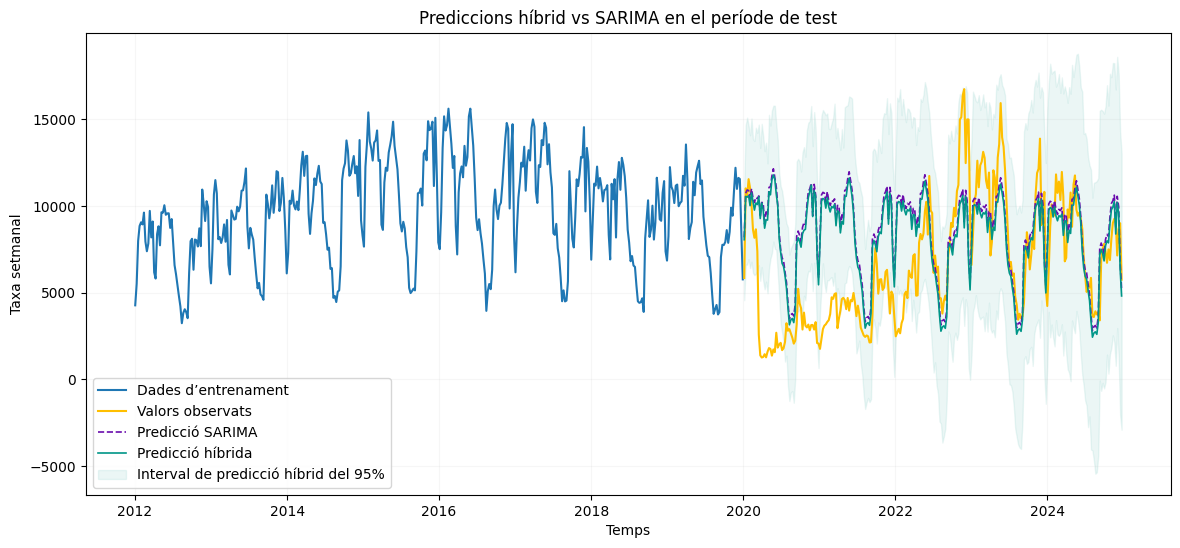

In [16]:
plt.figure(figsize=(14,6))

plt.plot(train, label='Dades d’entrenament', color=COLOR_TRAIN, linewidth=1.5)
plt.plot(test, label='Valors observats', color=COLOR_OBS, linewidth=1.5)

plt.plot(pred_mean, label='Predicció SARIMA', color=COLOR_FORECAST, linewidth=1.2, linestyle='--')
plt.plot(hybrid_pred_mean, label='Predicció híbrida', color=COLOR_HYBRID, linewidth=1.2)

plt.fill_between(
    hybrid_ci_lower.index,
    hybrid_ci_lower.values,
    hybrid_ci_upper.values,
    color=COLOR_HYBRID,
    alpha=0.08,
    label='Interval de predicció híbrid del 95%'
)

plt.legend()
plt.title("Prediccions híbrid vs SARIMA en el període de test")
plt.xlabel("Temps")
plt.ylabel("Taxa setmanal")
plt.grid(alpha=0.1)
plt.show()

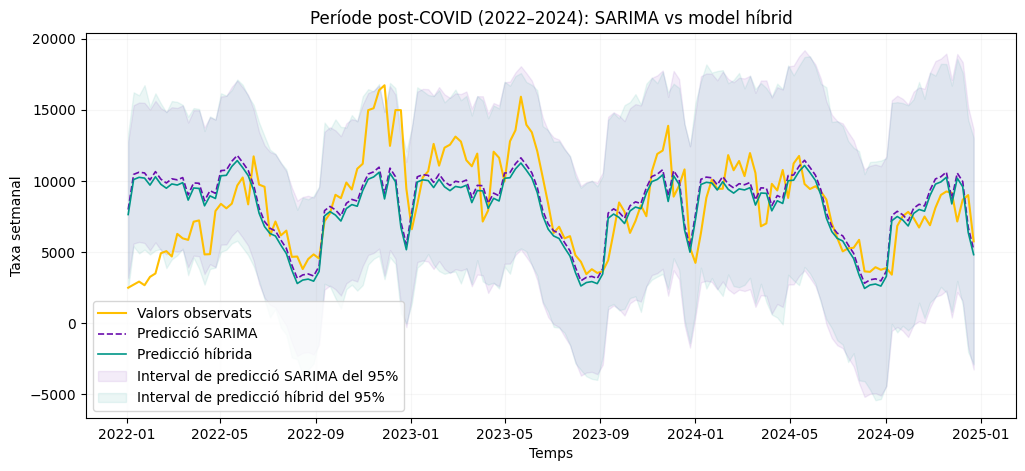

In [17]:
hybrid_covid = hybrid_pred_mean["2020":"2021"]

plt.figure(figsize=(12,5))

plt.plot(test_post, label='Valors observats', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_post, label='Predicció SARIMA', color=COLOR_FORECAST, linewidth=1.2, linestyle='--')
plt.plot(hybrid_post, label='Predicció híbrida', color=COLOR_HYBRID, linewidth=1.2)

plt.fill_between(
    ci_post.index,
    ci_post.iloc[:, 0],
    ci_post.iloc[:, 1],
    color=COLOR_FORECAST,
    alpha=0.08,
    label='Interval de predicció SARIMA del 95%'
)

plt.fill_between(
    hybrid_ci_post_lower.index,
    hybrid_ci_post_lower.values,
    hybrid_ci_post_upper.values,
    color=COLOR_HYBRID,
    alpha=0.08,
    label='Interval de predicció híbrid del 95%'
)

plt.title("Període post-COVID (2022–2024): SARIMA vs model híbrid")
plt.xlabel("Temps")
plt.ylabel("Taxa setmanal")
plt.legend()
plt.grid(alpha=0.1)
plt.show()

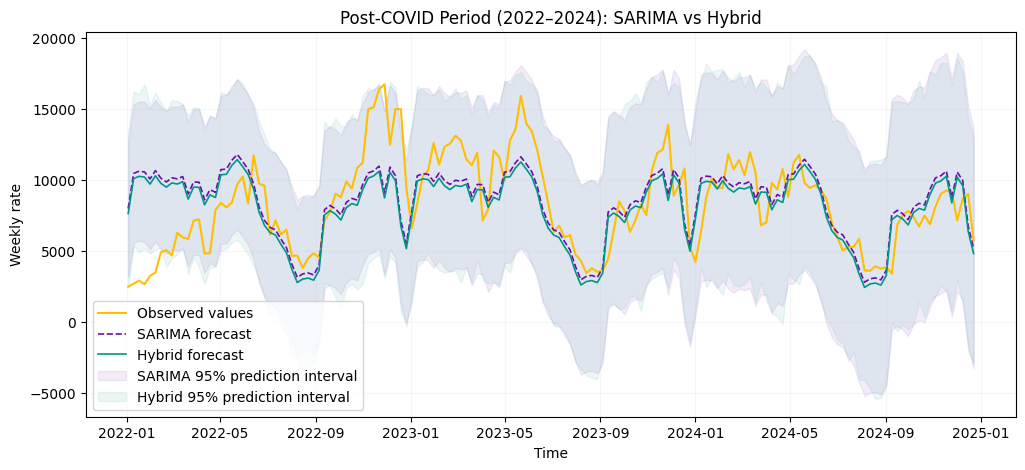

In [18]:
hybrid_post = hybrid_pred_mean["2022":"2024"]

plt.figure(figsize=(12,5))

plt.plot(test_post, label='Observed values', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_post, label='SARIMA forecast', color=COLOR_FORECAST, linewidth=1.2, linestyle='--')
plt.plot(hybrid_post, label='Hybrid forecast', color=COLOR_HYBRID, linewidth=1.2)

plt.fill_between(
    ci_post.index,
    ci_post.iloc[:, 0],
    ci_post.iloc[:, 1],
    color=COLOR_FORECAST,
    alpha=0.08,
    label='SARIMA 95% prediction interval'
)

plt.fill_between(
    hybrid_ci_post_lower.index,
    hybrid_ci_post_lower.values,
    hybrid_ci_post_upper.values,
    color=COLOR_HYBRID,
    alpha=0.08,
    label='Hybrid 95% prediction interval'
)

plt.title("Post-COVID Period (2022–2024): SARIMA vs Hybrid")
plt.xlabel("Time")
plt.ylabel("Weekly rate")
plt.legend()
plt.grid(alpha=0.1)
plt.show()

## Interpretació final dels resultats

El model híbrid SARIMA + NNAR estacional mostra una millora global moderada respecte al model SARIMA per si sol, reduint els errors de predicció en un 2,62% en MAE, un 3,25% en RMSE i un 4,09% en MAPE, alhora que proporciona una cobertura empírica lleugerament superior (0,762 enfront de 0,715).

Aquesta millora està impulsada principalment pel període COVID (2020–2021), en què el model híbrid presenta millors resultats en totes les mètriques d’error i també incrementa la cobertura empírica de 0,385 a 0,481. Els gràfics de predicció confirmen aquest resultat, tot i que també mostren que ambdós models tenen dificultats per captar la forta caiguda de la sèrie durant aquell període.

En el període post-COVID (2022–2024), les prediccions SARIMA i híbrida són visualment molt similars. Això és coherent amb les mètriques, ja que el model híbrid obté resultats lleugerament pitjors en precisió puntual, tot i que continua mostrant una cobertura empírica marginalment superior (0,949 enfront de 0,936).

En conjunt, la correcció NNAR sembla ser més útil sota les irregularitats més intenses del període COVID que no pas en el període posterior, on la seva contribució esdevé més limitada.